In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
from pandas.core.dtypes import astype
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from scipy.stats import pearsonr, spearmanr

%matplotlib inline

In [2]:
df_amz = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [105]:
df_amz = df_amz[df_amz['stars'] > 0]
df_amz["stars"].value_counts()

stars
4.5    151577
4.6    136995
4.4    136165
5.0    128492
4.3    112564
4.7     94566
4.2     86871
4.0     66089
4.1     65115
4.8     41858
3.9     36555
3.8     27876
3.7     21137
3.6     16219
3.5     14673
3.0     12819
4.9     11081
3.4     10355
1.0      8484
3.3      8269
3.2      5771
3.1      4679
2.0      3901
2.9      3341
2.8      2306
2.7      2104
2.5      2103
2.6      1579
2.4      1060
2.3       734
2.2       602
2.1       540
1.5       404
1.9       300
1.8       249
1.7       177
1.4       149
1.6       147
1.3        78
1.2        23
1.1         3
Name: count, dtype: int64

#### Part 1 - Crosstab Analysis

In [106]:
contingency_proportions = pd.crosstab(df_amz["category"], df_amz["isBestSeller"], normalize='index').sort_values(by=[True], ascending=False)

In [107]:
(contingency_proportions * 100).round(2)

isBestSeller,False,True
category,,
Material Handling Products,87.88,12.12
Smart Home Security & Lighting,92.21,7.79
Test & Measurement,94.00,6.00
Grocery,94.16,5.84
Health & Personal Care,94.23,5.77
...,...,...
Boxes & Organisers,100.00,0.00
Snowboard Boots,100.00,0.00
Boating Footwear,100.00,0.00


In [108]:
contingency = pd.crosstab(df_amz["category"], df_amz["isBestSeller"])

#### Part 1 - Statistical Tests

In [109]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

In [110]:
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 15380.142540443778
p-value: 0.0


In [111]:
cramers_v = association(contingency, method='cramer')
print("Cramér's V:", cramers_v)

Cramér's V: 0.11237113132728344


#### Part 1 - Visualizations

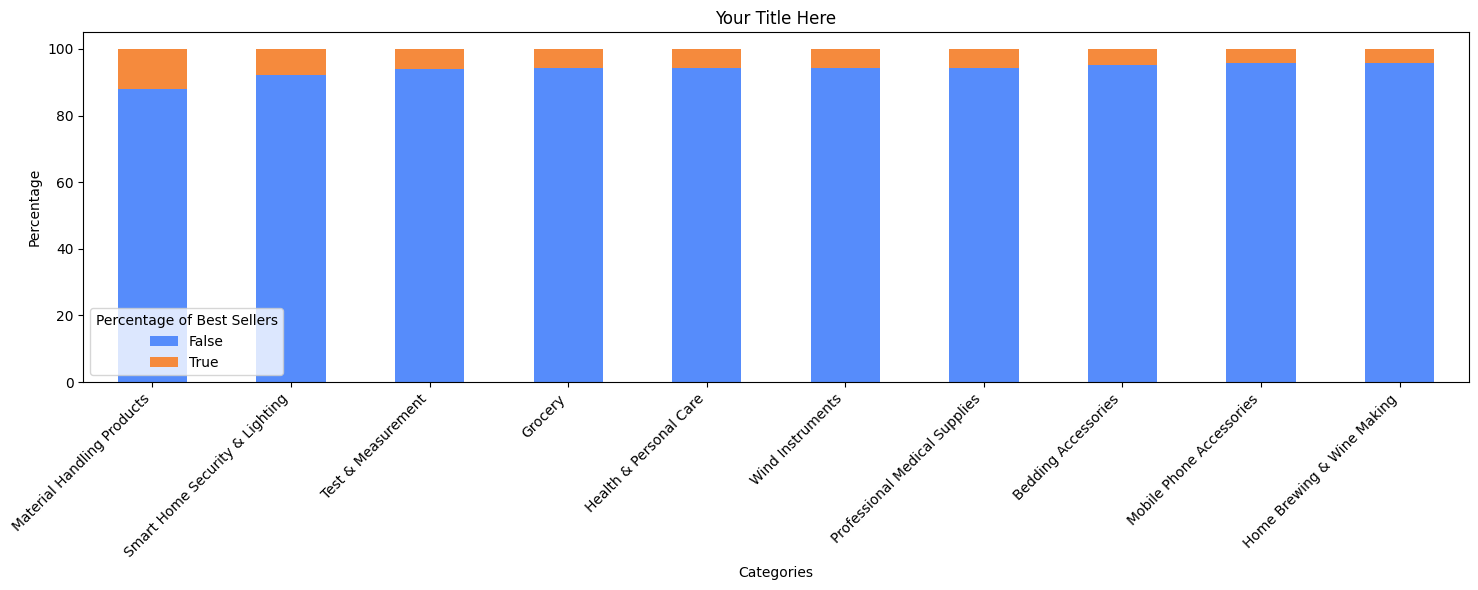

In [112]:
crosstab_data = pd.crosstab(df_amz["category"], df_amz["isBestSeller"], normalize='index').sort_values(by=[True], ascending=False).head(10)
crosstab_data = (crosstab_data * 100).round(2)
# Plot
crosstab_data.plot(kind='bar', stacked=True, figsize=(15, 6))

plt.title('Your Title Here')
plt.xlabel('Categories')
plt.ylabel('Percentage')
plt.legend(title='Percentage of Best Sellers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

####  Part 2 - Preliminary Step: Remove outliers

In [113]:
Q1 = df_amz['price'].quantile(0.25)
Q3 = df_amz['price'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(25.86)

In [114]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [115]:
df_no_outliers = df_amz[(df_amz['price'] >= lower_bound) & (df_amz['price'] <= upper_bound)]

#### Part 2 - Violin Plots

In [117]:
top_20_categories = df_no_outliers['category'].value_counts().head(20).index

df_top_20 = df_no_outliers[df_no_outliers['category'].isin(top_20_categories)]

df_top_20

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
19513,21072,B09477KHQ3,"Personalised Birthday Print Gift ""THE YEAR YOU...",4.5,763,7.99,False,900,Handmade Home & Kitchen Products
19514,21073,B0BSRFQYG8,Wax Melts 4 Bars | Build Your Own Box (Choose ...,3.9,117,6.49,True,800,Handmade Home & Kitchen Products
19515,21074,B09N9GVHV9,"Personalised Birthday Print Gift ""ON THE DAY/Y...",4.6,1155,8.99,True,600,Handmade Home & Kitchen Products
19516,21075,B0BRYGV7PQ,Fresh Wax Melts - Laundry Type Wax Melts - Str...,4.5,56,4.99,True,500,Handmade Home & Kitchen Products
19517,21076,B0B1JHB28R,Manta Makes Work Leaving Gifts | I Used to Wor...,4.7,261,9.95,True,400,Handmade Home & Kitchen Products
...,...,...,...,...,...,...,...,...,...
2397634,2767899,B000HGPG3S,Marmot Marmot Ladies' Tempo Vest - ATOMIC BLUE...,4.0,1,71.65,False,0,Sports & Outdoors
2397652,2767930,B00DZO0K5I,Trespass Girl's Vee Jacket,4.4,37,26.38,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


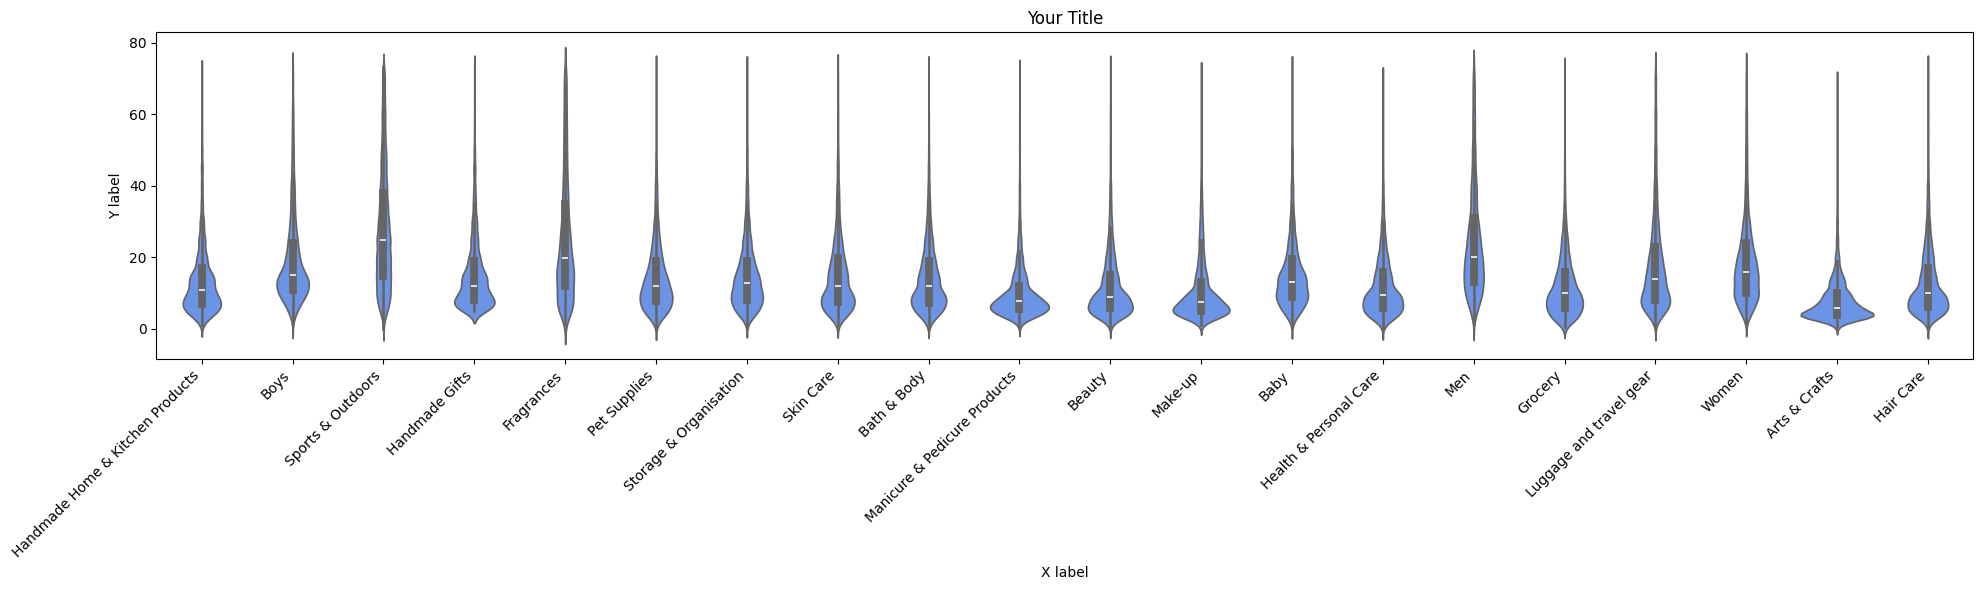

In [118]:
plt.figure(figsize=(20, 6))

sns.violinplot(data=df_top_20, x='category', y='price')

plt.title('Your Title')
plt.xlabel('X label')
plt.ylabel('Y label')
plt.xticks(rotation=45, ha='right')  # if category labels are long
plt.tight_layout()
plt.show()

#### Part 2 - Bar Charts

In [119]:
top_10_categories = df_no_outliers['category'].value_counts().head(10).index

df_top_10 = df_no_outliers[df_no_outliers['category'].isin(top_10_categories)]

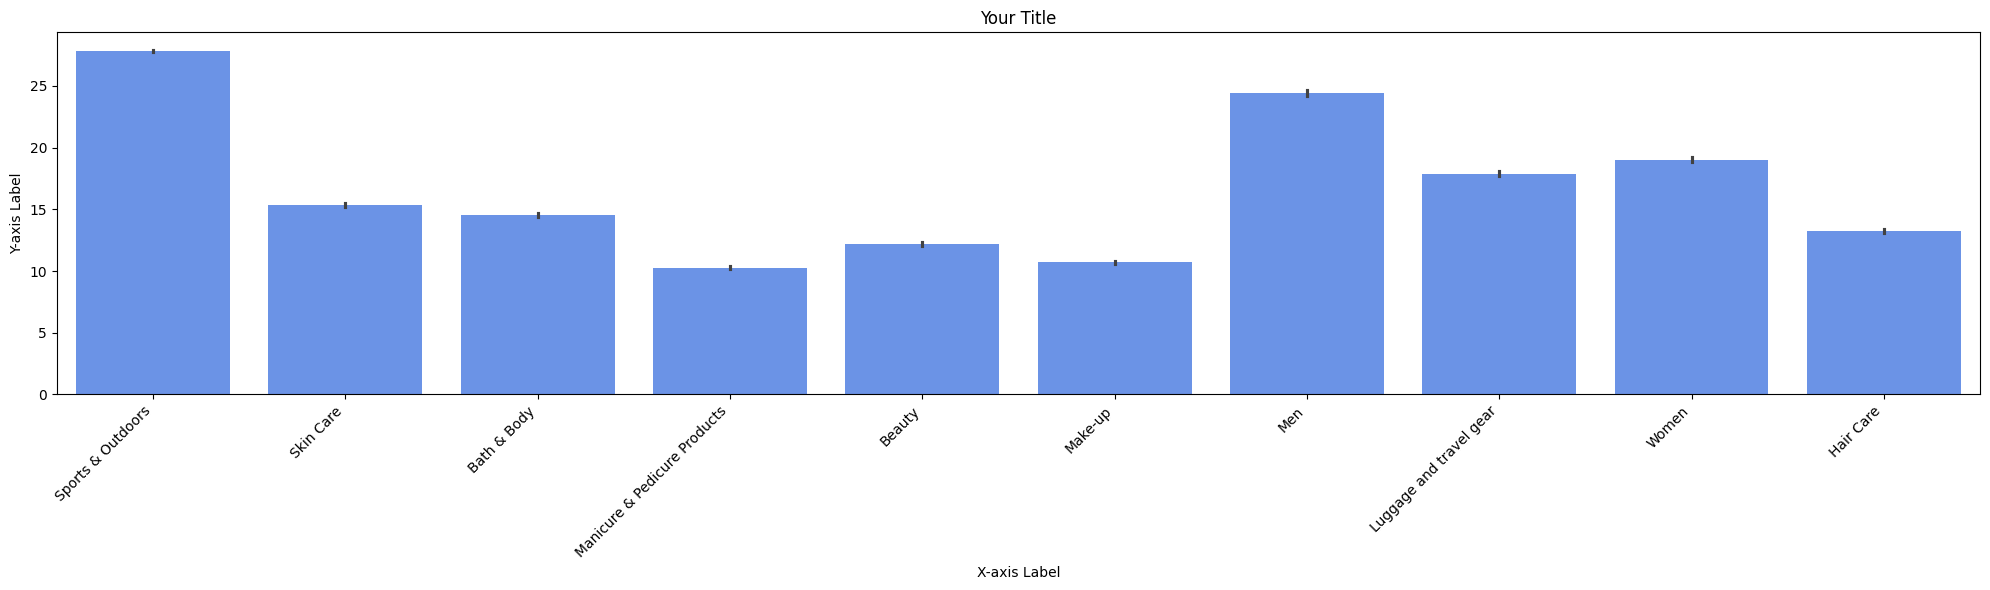

In [120]:
plt.figure(figsize=(20, 6))

sns.barplot(data=df_top_10, x='category', y='price')

plt.title('Your Title')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Part 2 - Box Plots

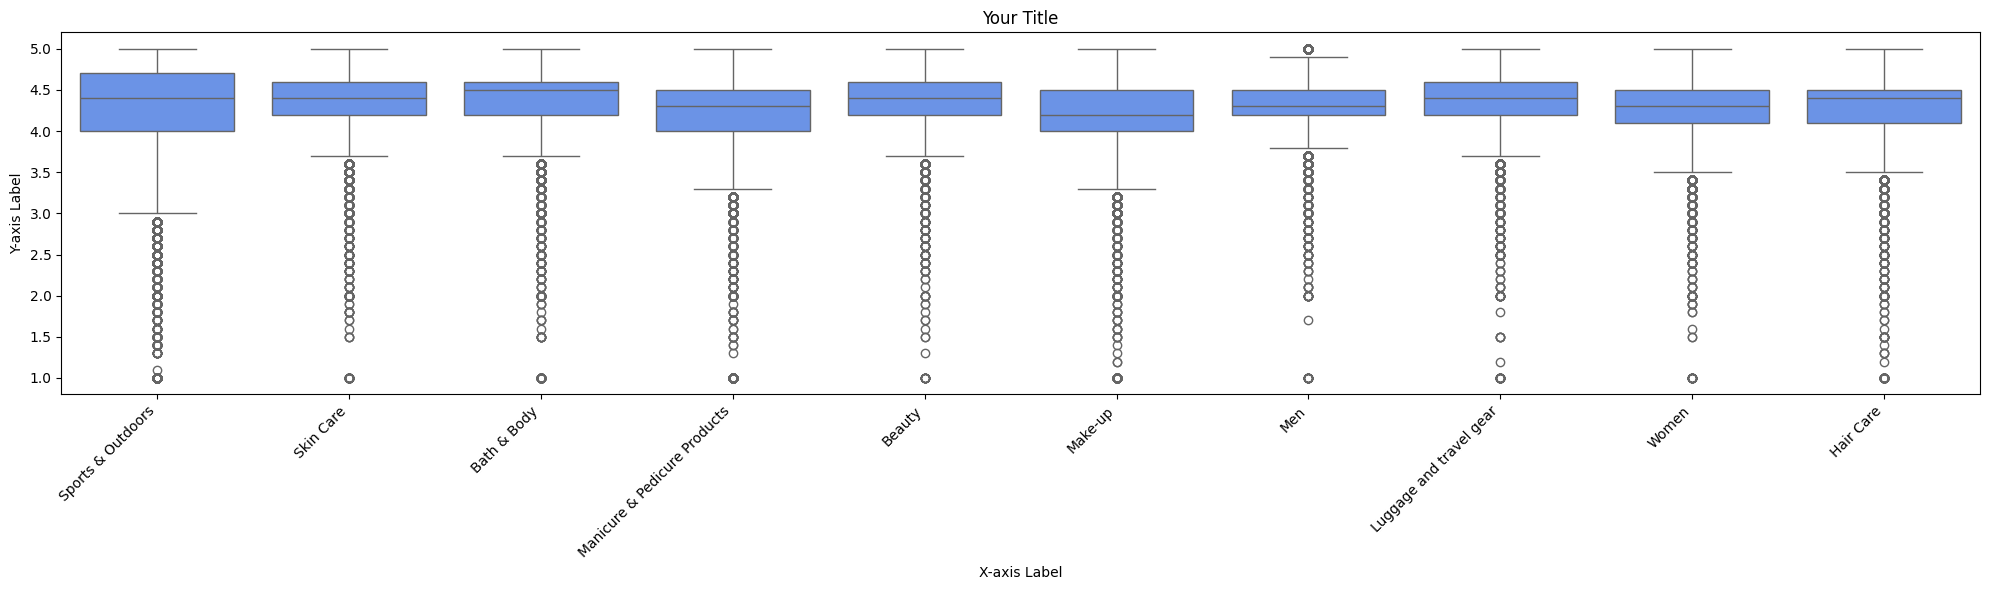

In [121]:
plt.figure(figsize=(20, 6))

sns.boxplot(data=df_top_10, x='category', y='stars')

plt.title('Your Title')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Part 3 - Correlation Coefficients

In [122]:
pearson_corr, pearson_p = pearsonr(df_no_outliers['price'], df_no_outliers['stars'])

print(f"Pearson: {pearson_corr:.4f}, p: {pearson_p:.4f}")

Pearson: 0.0105, p: 0.0000


#### Part 3 - Visualizations

In [134]:
df_sample = df_no_outliers.sample(n=1000, random_state=42)

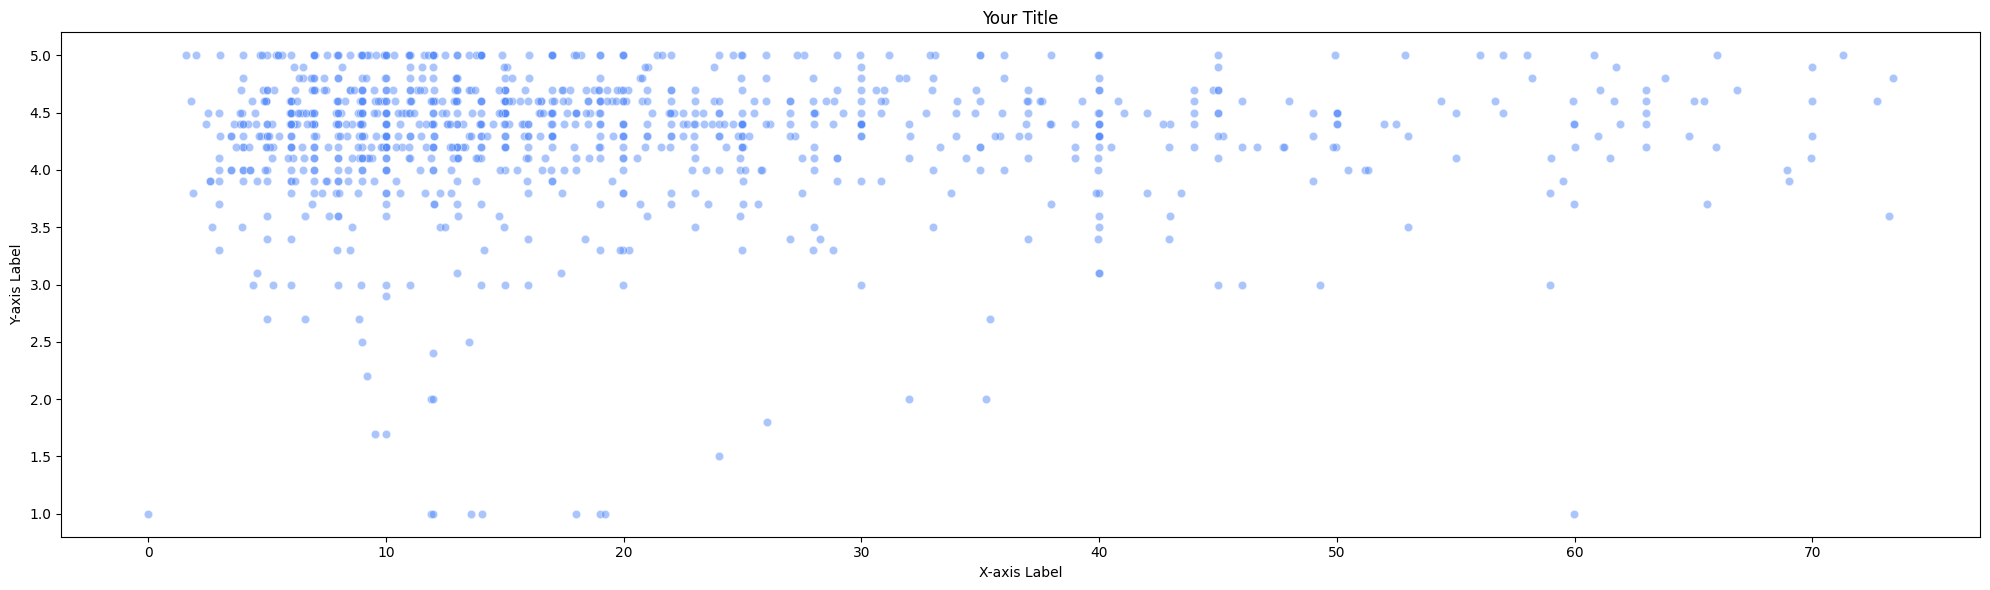

In [135]:
plt.figure(figsize=(20, 6))

sns.scatterplot(data=df_sample, x='price', y='stars', alpha=0.5)


plt.title('Your Title')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.tight_layout()
plt.show()

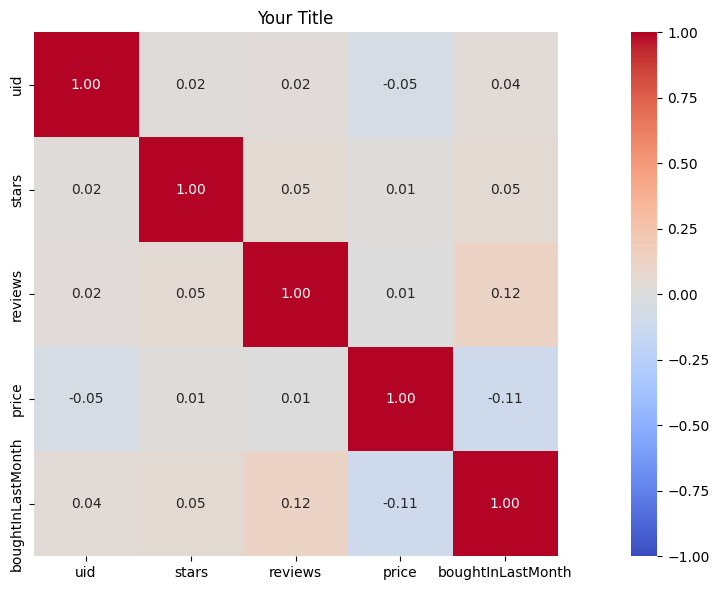

In [140]:
corr_matrix = df_sample.select_dtypes(include="number").corr(method='pearson')

plt.figure(figsize=(15, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    vmin=-1, vmax=1
)

plt.title('Your Title')
plt.tight_layout()
plt.show()

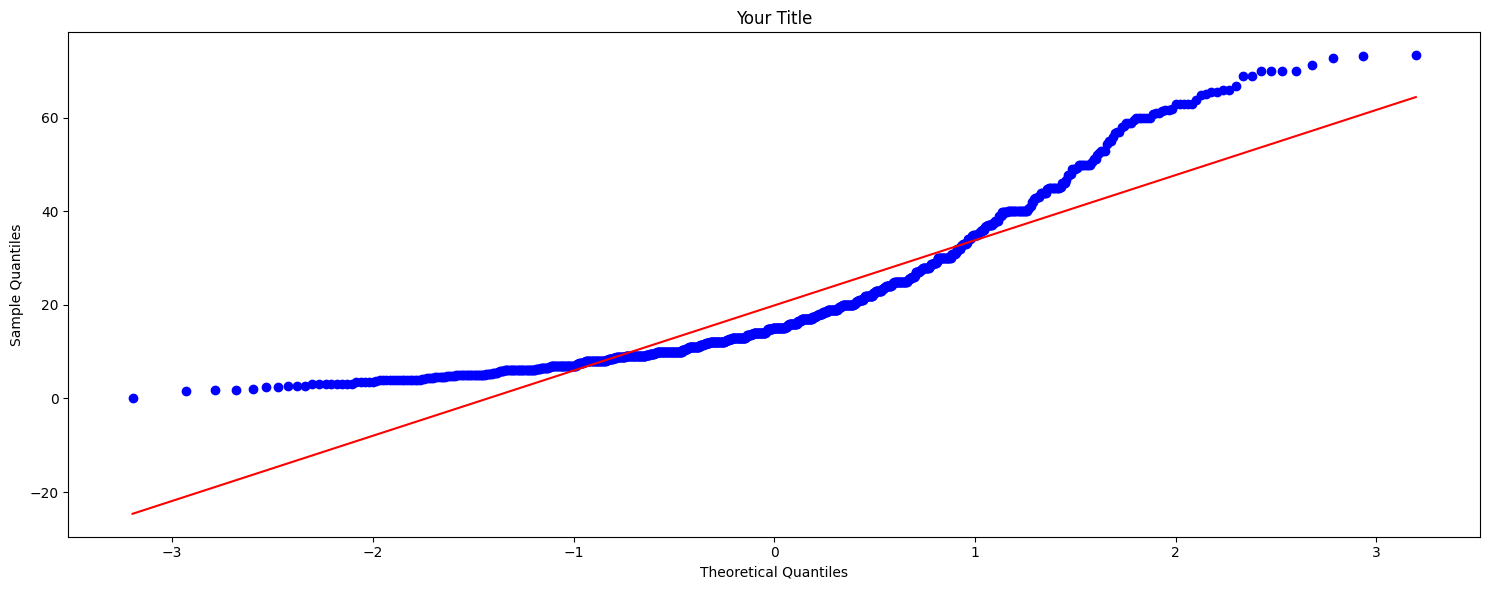

In [141]:
plt.figure(figsize=(15, 6))

stats.probplot(df_sample['price'], dist='norm', plot=plt)

plt.title('Your Title')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.tight_layout()
plt.show()

# Findings: Amazon UK Product Insights — Bivariate EDA

## Part 1 — Best Seller Trends Across Categories


The crosstab of category vs isBestSeller revealed that bestsellers are extremely rare overall: even in the top 10 categories, the bestseller share is only between ~6% and ~12%. Outside the top, most categories sit below 6%.

The categories with the highest proportion of bestsellers are: Material Handling Products, Smart Home Security & Lighting, Test & Measurement, Grocery and Health & Personal Care.

The Chi-square test of independence returned χ² = 15,380.14, p ≈ 0, so we reject the null hypothesis, which means that category and bestseller status are not independent. However, Cramér's V = 0.112, indicates a weak association in absolute terms. This could be because of the huge sample size that makes any tiny effect look "highly significant", so the effect-size measure (Cramér's V) is what tells us how much category actually matters in practice.

---

## Part 2 — Product Prices and Ratings Across Categories and Brands

The **violin plots** for the top 20 categories show that, even after outlier removal, all price distributions remain strongly right-skewed: most products cluster at the low end with a long tail extending toward £75+. There are clear differences in central tendency:

Sports & Outdoors and Men  stand out as the most expensive of the top 10 categories.
Women and Luggage and travel gear are mid-range.
Manicure & Pedicure Products, Make-up and Beauty are the cheapest.


The **bar plot** of mean price across the top 10 categories makes the category differences much easier to read than the violins do, because it strips away the distribution and just shows the average:

Sports & Outdoors is clearly the most expensive category.
Men is the second-highest.
Women and Luggage and travel gear sit in the middle.
Skin Care, Bath & Body and Hair Care are mid-low.
Beauty, Make-up and Manicure & Pedicure Products are the cheapest.

The **box plots**  of ratings by category tell a very different story. The median rating is 4.3–4.4 in every single one of the top 10 categories, with the IQR roughly between 4.0 and 4.6. All categories show a long tail of low-rating outliers (1.0–3.5).
So, category clearly influences price but provides almost no information about rating.

---

## Part 3 — Relation between products prices and products rating

Pearson correlation between price and stars: r = 0.0105 (p ≈ 0). The p-value is "significant" only because we have a huge sample. There is no meaningful linear relationship between price and rating.

The **scatter plot** confirms this visually: at every price level, ratings concentrate in the 4.0–5.0 band, with low-rating points scattered fairly uniformly across the price axis. There is no rising or falling trend.

The **correlation heatmap** of all numeric variables backs this up that every correlation involving rating and price is below 0.05 in absolute value.

The **Q-Q plot** of price shows the sample quantiles diverging strongly from the theoretical normal line, especially in the upper tail. Price is clearly not normally distributed even after outlier removal, it remains heavy-tailed and right-skewed.

Price and rating are essentially independent in this dataset. A more expensive product is not a better-rated one, and a cheaper product is not a worse-rated one.